In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import myplotlib
import myplotlib.plots as myplt
import compton
myplotlib.load()


In [30]:
energies_0 = None
energies_1 = None
    
with h5py.File("../prtl.tot.00100", "r") as f:
    energies_0 = np.sqrt(f["u_3"][:]**2 + f["v_3"][:]**2 + f["w_3"][:]**2)
    
with h5py.File("../build/ssc1.h5", "r") as f:
    energies_1 = f["e_ph"][:]


Text(0, 0.5, '$\\varepsilon f(\\varepsilon)$')

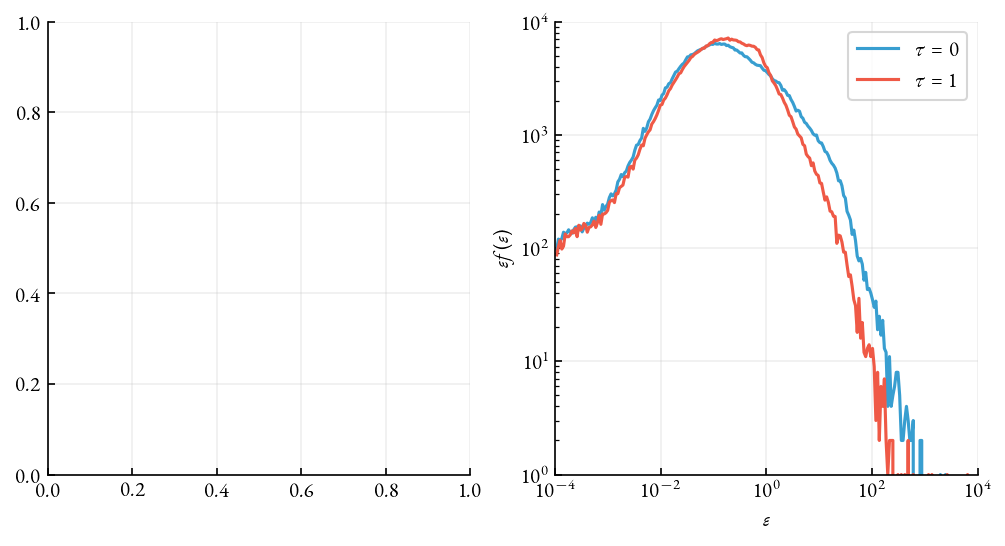

In [31]:
fig = plt.figure(figsize=(8, 4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

ebins = np.logspace(-4, 4, 250)

e0, _ = np.histogram(energies_0, bins=ebins)
e1, _ = np.histogram(energies_1, bins=ebins)

lims = dict(xlog=True, ylog=True, xlim=(1e-4, 1e4), ylim=(1, 1e4))
myplt.plot(ax2, ebins[1:], e0, **lims, c='C0', label=r"$\tau=0$")
myplt.plot(ax2, ebins[1:], e1, **lims, c='C1', label=r"$\tau=1$")
plt.legend()

ax2.set_xlabel(r"$\varepsilon$")
ax2.set_ylabel(r"$\varepsilon f(\varepsilon)$")
